# Salary Prediction: Version 3.0

## Setup

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import joblib

## Loading Dataset

In [41]:
df_full = pd.read_csv("../data/recalculated_performance_data.csv", delimiter=",")
df_full.head()

,employee_id,Job_Title,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,...,digital_score,hard_score,wellness_score,productivity_index,performance_score_original,composite_score,rating_label,group,department,seniority
0,c4c45a01-39e8-4561-b936-fcf185b49920,Consultant (Cloud & Infra),Bachelor's,3,3733.33,50.4,32,405,3,62,...,2.980654,2.502463,3.175713,2.780570,4,7.02,Meets expectations,pregnant,Cloud & Infra,Mid
1,51b2928a-4091-4430-97a6-50e6fea44476,Senior Consultant (Cybersecurity),Master's,2,6550.00,18.9,22,0,86,17,...,2.025195,1.539715,3.021699,1.981756,2,5.73,Partially meets,pregnant,Cybersecurity,Senior
2,01229a5b-b84d-4192-8dd3-429f7e705ba1,Junior Consultant (Cybersecurity),High School,2,2833.33,40.2,24,9,9,39,...,2.144163,1.815590,3.195668,2.190178,3,6.73,Meets expectations,pregnant,Cybersecurity,Junior
3,a04f499a-83c0-49bd-b0d9-3c8783d5fad3,Junior Consultant (Cloud & Infra),High School,2,2350.00,32.6,22,0,5,31,...,1.686067,1.589319,3.035281,1.907536,3,5.85,Partially meets,pregnant,Cloud & Infra,Junior
4,c791ec00-e86c-4e0a-b500-f75ae927521f,Consultant (Digital Transformation),Bachelor's,3,3191.67,33.5,26,0,67,33,...,3.044602,2.037041,3.189319,2.569765,4,7.35,Meets expectations,pregnant,Digital Transformation,Mid


## Exploratory Data Analysis: Feature Selection

In [42]:
all_cols = df_full.columns.tolist()
print(all_cols)

['employee_id', 'Job_Title', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'digital_score', 'hard_score', 'wellness_score', 'productivity_index', 'performance_score_original', 'composite_score', 'rating_label', 'group', 'department', 'seniority']


In [43]:
object_cols = [col for col in all_cols if df_full[col].dtype == "object"]
cardinality = {col: df_full[col].nunique() for col in object_cols}
sorted(cardinality.items(), key=lambda x: x[1])

[('Education_Level', 3),
 ('rating_label', 3),
 ('group', 3),
 ('seniority', 4),
 ('department', 5),
 ('Job_Title', 20),
 ('employee_id', 1500)]

The following columns are excluded from the model:

- **employee_id**: Unique identifier with no predictive value
- **group**: Demographic group (pregnant, non_pregnant_f, male) — excluded to prevent direct bias; retained separately for the post-hoc fairness analysis
- **department**: Redundant with `Job_Title`, which already encodes the specialisation
- **seniority**: Encoded implicitly within `Job_Title` (Junior / Consultant / Senior / Managing)
- **rating_label**: Categorical string label derived directly from `Performance_Score`; would introduce leakage since it encodes the target derivation
- **performance_score_original**: The pre-adjustment score; including it alongside `Performance_Score` would introduce multicollinearity and leak adjustment logic

In [44]:
cols_to_drop = [
    "employee_id", "group", "department", "seniority",
    "rating_label", "performance_score_original"
]

# Preserve group for fairness analysis
df_groups = df_full[["employee_id", "group"]].copy()

df = df_full.drop(columns=cols_to_drop)
df.head()

,Job_Title,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,digital_score,hard_score,wellness_score,productivity_index,composite_score
0,Consultant (Cloud & Infra),Bachelor's,3,3733.33,50.4,32,405,3,62,5,60,2.980654,2.502463,3.175713,2.780570,7.02
1,Senior Consultant (Cybersecurity),Master's,2,6550.00,18.9,22,0,86,17,5,55,2.025195,1.539715,3.021699,1.981756,5.73
2,Junior Consultant (Cybersecurity),High School,2,2833.33,40.2,24,9,9,39,5,66,2.144163,1.815590,3.195668,2.190178,6.73
3,Junior Consultant (Cloud & Infra),High School,2,2350.00,32.6,22,0,5,31,5,65,1.686067,1.589319,3.035281,1.907536,5.85
4,Consultant (Digital Transformation),Bachelor's,3,3191.67,33.5,26,0,67,33,5,61,3.044602,2.037041,3.189319,2.569765,7.35


## Exploratory Data Analysis: Checking Performance Score Distribution

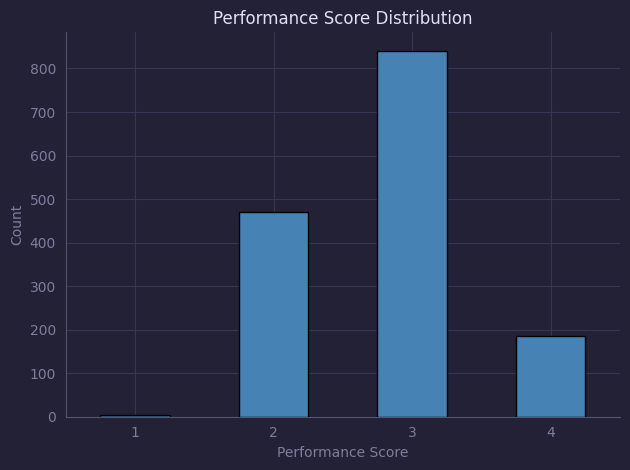

In [45]:
score_counts = df["Performance_Score"].value_counts().sort_index()
score_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Performance Score")
plt.ylabel("Count")
plt.title("Performance Score Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.style.use('./rose-pine-moon.mplstyle')
plt.show()

## Exploratory Data Analysis: Checking Monthly Salary w.r.t Job Title

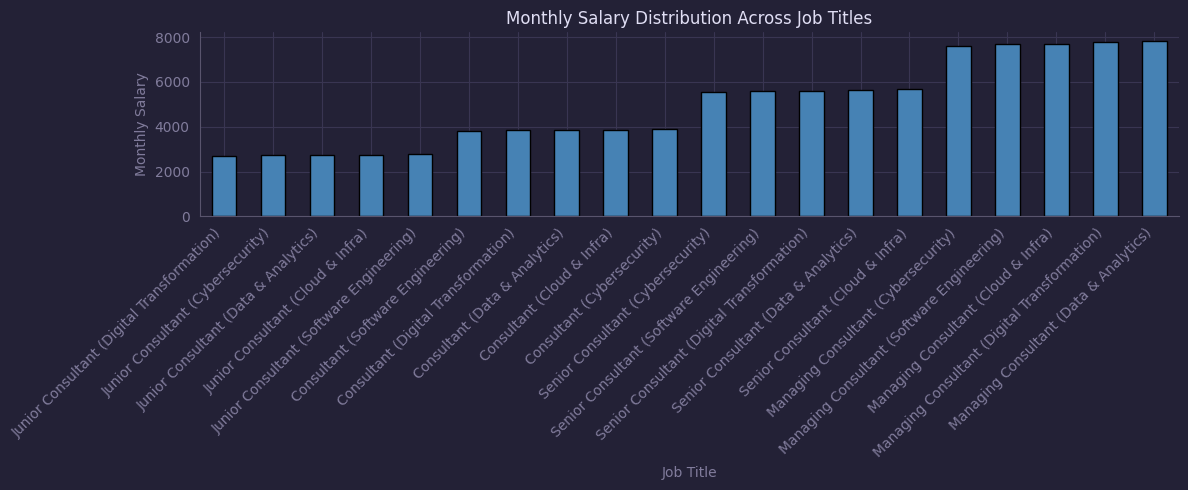

In [46]:
avg_salary_for_jobs = df.groupby("Job_Title")["Monthly_Salary"].mean().sort_values()
avg_salary_for_jobs.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(12, 5))
plt.xlabel("Job Title")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Job Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Monthly Salary w.r.t Education Level

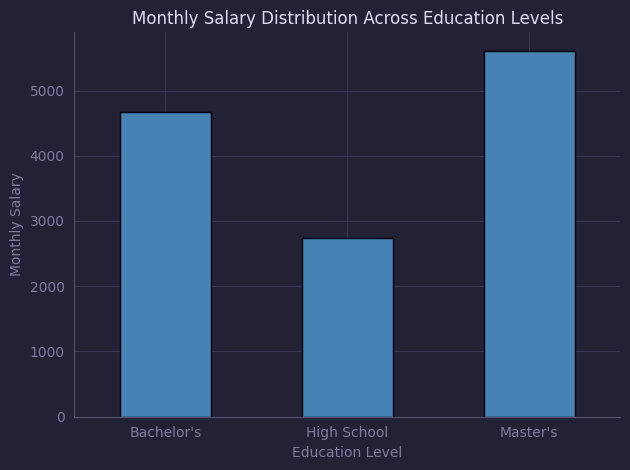

In [47]:
avg_salary_for_edu = df.groupby("Education_Level")["Monthly_Salary"].mean()
avg_salary_for_edu.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Education Level")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Education Levels")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Feature-Target Relationship

In [48]:
# Load feature info saved by the performance notebook
cols_info = joblib.load("../data/processed/performance_feature_info.pkl")
for key, value in cols_info.items():
    locals()[key] = value

numeric_cols     = cols_info["numeric_cols"]
categorical_cols = cols_info["categorical_cols"]
ordinal_cols     = cols_info["ordinal_cols"]
onehot_cols      = cols_info["onehot_cols"]

target_col_sal = "Monthly_Salary"
print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

Numeric cols: ['Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'digital_score', 'hard_score', 'wellness_score', 'productivity_index', 'composite_score', 'capacity_mean', 'physical_mean', 'mental_mean', 'energy_mean', 'wellness_index']
Categorical cols: ['Job_Title', 'Education_Level']


In [49]:
valid_numeric_cols = [
    col for col in numeric_cols
    if col in df.columns and df[col].nunique() > 1
]

df[valid_numeric_cols].corrwith(df[target_col_sal]).sort_values(ascending=False)

Monthly_Salary           1.000000
productivity_index       0.395681
hard_score               0.394951
digital_score            0.391398
Remote_Work_Frequency    0.288281
Projects_Handled         0.272695
Overtime_Hours           0.182911
Work_Hours_Per_Week      0.151516
composite_score          0.096768
wellness_score           0.030975
Sick_Days               -0.003751
Training_Hours          -0.913831
dtype: float64

In [50]:
for col in categorical_cols:
    groups = [df[df[col] == val][target_col_sal] for val in df[col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{col}:")
    print(f"  ANOVA p-value: {p_value:.6f}")
    if p_value < 0.05:
        print(f"  - Statistically significant at 95% confidence")
        print(df.groupby(col)[target_col_sal].mean())
    else:
        print(f"  - Not statistically significant at 95% confidence")


Job_Title:
  ANOVA p-value: 0.000000
  - Statistically significant at 95% confidence
Job_Title
Consultant (Cloud & Infra)                      3859.959268
Consultant (Cybersecurity)                      3908.937174
Consultant (Data & Analytics)                   3856.336033
Consultant (Digital Transformation)             3846.828938
Consultant (Software Engineering)               3830.480450
Junior Consultant (Cloud & Infra)               2761.158136
Junior Consultant (Cybersecurity)               2722.557586
Junior Consultant (Data & Analytics)            2748.039412
Junior Consultant (Digital Transformation)      2708.870806
Junior Consultant (Software Engineering)        2783.333400
Managing Consultant (Cloud & Infra)             7714.583929
Managing Consultant (Cybersecurity)             7599.107143
Managing Consultant (Data & Analytics)          7825.225135
Managing Consultant (Digital Transformation)    7769.891613
Managing Consultant (Software Engineering)      7697.148684
Seni

## Data Preprocessing: Data Splitting

In [51]:
features_col_sal = [c for c in df.columns if c != target_col_sal]
X = df[features_col_sal]
y = df[target_col_sal]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1200, 15), Test: (300, 15)


## Data Preprocessing: Encoding Categorical Variables as Numeric

In [52]:
print("Education_Level unique:", X_train["Education_Level"].unique())

Education_Level unique: ["Master's" 'High School' "Bachelor's"]


In [53]:
education_order = [["High School", "Bachelor's", "Master's"]]
print("Ordinal cols:", ordinal_cols)

Ordinal cols: ['Education_Level']


In [54]:
print("Job_Title unique:", X_train["Job_Title"].unique())
print("\nOne-hot cols:", onehot_cols)

Job_Title unique: ['Senior Consultant (Data & Analytics)'
 'Junior Consultant (Cloud & Infra)'
 'Senior Consultant (Software Engineering)'
 'Junior Consultant (Software Engineering)'
 'Consultant (Data & Analytics)' 'Consultant (Cybersecurity)'
 'Managing Consultant (Data & Analytics)'
 'Senior Consultant (Cloud & Infra)' 'Consultant (Digital Transformation)'
 'Junior Consultant (Data & Analytics)' 'Consultant (Cloud & Infra)'
 'Consultant (Software Engineering)'
 'Senior Consultant (Digital Transformation)'
 'Junior Consultant (Cybersecurity)'
 'Managing Consultant (Digital Transformation)'
 'Managing Consultant (Cybersecurity)' 'Senior Consultant (Cybersecurity)'
 'Junior Consultant (Digital Transformation)'
 'Managing Consultant (Software Engineering)'
 'Managing Consultant (Cloud & Infra)']

One-hot cols: ['Job_Title']


## Data Preprocessing: Creating a Column Transformer

In [55]:
numeric_features_sal = [c for c in numeric_cols if c in features_col_sal]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),                                  numeric_features_sal),
        ("ordinal", OrdinalEncoder(categories=education_order),        ordinal_cols),
        ("onehot",  OneHotEncoder(drop="first", sparse_output=False),  onehot_cols),
    ],
    remainder="passthrough"
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## Model: Selection Rationale

Five regression models are selected for salary prediction:

1. **Linear Regression**: Baseline model with interpretable coefficients.
2. **Ridge Regression**: L2-regularised; handles multicollinearity.
3. **Random Forest Regressor**: Ensemble; captures non-linear feature interactions.
4. **Gradient Boosting Regressor**: Sequential boosting; effective for complex patterns.
5. **XGBoost Regressor**: Optimised gradient boosting; state-of-the-art on tabular data.

In [56]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

## Model: Cross-Validation

In [57]:
cv_results = {}

for name, model in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5,
                                scoring="neg_mean_squared_error", n_jobs=-1)
    cv_results[name] = {"mean_cv_score": cv_scores.mean(), "std_cv_score": cv_scores.std(), "cv_scores": cv_scores}
    print(f"{name}: neg MSE = {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Linear Regression: neg MSE = -295531.6933 (+/- 18921.7865)
Ridge Regression: neg MSE = -316831.8897 (+/- 13700.5951)
Random Forest: neg MSE = -305034.4363 (+/- 23178.3746)
Gradient Boosting: neg MSE = -301329.1277 (+/- 26453.5211)
XGBoost: neg MSE = -362625.4270 (+/- 64360.2916)


## Model: Identifying Overfitting

In [58]:
unique_mapping = df.groupby(features_col_sal)[target_col_sal].nunique()
print(f"Total unique feature combinations: {len(unique_mapping)}")
print(f"Combinations with differing salaries: {(unique_mapping > 1).sum()}")
print(f"Deterministic percentage: {(unique_mapping == 1).sum() / len(unique_mapping) * 100:.2f}%")

Total unique feature combinations: 1500
Combinations with differing salaries: 0
Deterministic percentage: 100.00%


## Model: Training & Evaluation

In [59]:
cv_comparison = pd.DataFrame({
    name: {"Mean CV NMSE": cv_results[name]["mean_cv_score"],
           "Std CV NMSE":  cv_results[name]["std_cv_score"]}
    for name in cv_results
}).T
cv_comparison

,Mean CV NMSE,Std CV NMSE
Linear Regression,-295531.693251,9460.893261
Ridge Regression,-316831.889735,6850.297528
Random Forest,-305034.436274,11589.187321
Gradient Boosting,-301329.127682,13226.760561
XGBoost,-362625.426954,32180.145805


In [60]:
best_model_name = cv_comparison.sort_values("Mean CV NMSE", ascending=False).index[0]
best_model      = models[best_model_name]
print(f"Selected model: {best_model_name}")
print(f"Neg MSE (5-fold cv): {cv_comparison.loc[best_model_name, 'Mean CV NMSE']:.4f}")

Selected model: Linear Regression
Neg MSE (5-fold cv): -295531.6933


In [61]:
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [62]:
y_test_pred = best_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae  = mean_absolute_error(y_test, y_test_pred)
r2   = r2_score(y_test, y_test_pred)

print(f"RMSE:     {rmse:.2f}")
print(f"MAE:      {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

RMSE:     541.77
MAE:      434.92
R2 Score: 0.8864


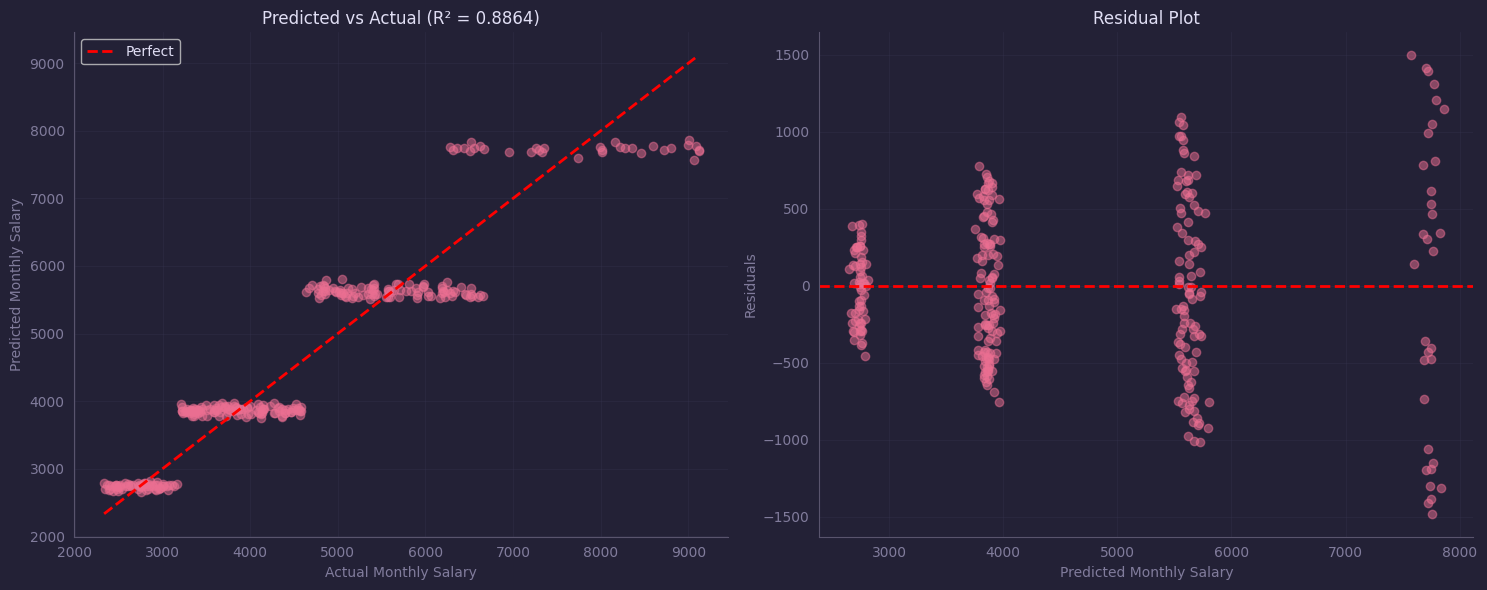

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_test_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect")
axes[0].set_xlabel("Actual Monthly Salary")
axes[0].set_ylabel("Predicted Monthly Salary")
axes[0].set_title(f"Predicted vs Actual (R² = {r2:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test.values - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Monthly Salary")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Saving Model & Preprocessing Objects

In [64]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/salary_prediction_model.pkl")
print("Salary model saved.")

Salary model saved.


## Fairness Analysis: Predicted Salary Across Groups

This section evaluates whether the trained salary model produces systematically different predictions for the three demographic groups (**pregnant**, **non_pregnant_f**, **male**).

The `group` column was deliberately excluded from model training. Here we re-attach it to the **full dataset** and compare:

1. **Mean `Monthly_Salary`** (ground-truth from the dataset)
2. **Mean model-predicted salary**
3. **Mean `Performance_Score`** (adjusted performance used as a feature)
4. **Mean `productivity_index`** (composite productivity metric)

A fair model should predict similar average salaries for groups with comparable feature profiles.

In [65]:
df_bias = df_full.copy()

X_all = df_full[features_col_sal]
pred_salary_all = best_pipeline.predict(X_all)
df_bias["predicted_salary"] = pred_salary_all

print(df_bias.groupby("group")[["Monthly_Salary", "predicted_salary"]].describe().round(2))

               Monthly_Salary                                               \
                        count     mean      std      min      25%      50%   
group                                                                        
male                    500.0  4649.02  1643.29  2358.33  3358.33  4354.16   
non_pregnant_f          500.0  4632.23  1542.48  2333.33  3400.00  4350.00   
pregnant                500.0  4512.05  1561.23  2341.67  3325.00  4154.16   

                                 predicted_salary                             \
                    75%      max            count     mean      std      min   
group                                                                          
male            5816.67  9116.67            500.0  4656.65  1538.69  2659.94   
non_pregnant_f  5583.33  9000.00            500.0  4623.06  1490.13  2668.99   
pregnant        5554.17  9083.33            500.0  4531.97  1453.28  2651.02   

                                                  

In [66]:
group_sal = df_bias.groupby("group").agg(
    n                      = ("group",             "count"),
    mean_actual_salary     = ("Monthly_Salary",    "mean"),
    mean_predicted_salary  = ("predicted_salary",  "mean"),
    mean_perf_score        = ("Performance_Score", "mean"),
    mean_productivity_index= ("productivity_index","mean"),
).round(4)

print("Salary, Performance & Productivity by Group:")
print(group_sal.to_string())

Salary, Performance & Productivity by Group:
                  n  mean_actual_salary  mean_predicted_salary  mean_perf_score  mean_productivity_index
group                                                                                                   
male            500           4649.0167              4656.6497            2.994                   2.9896
non_pregnant_f  500           4632.2333              4623.0556            2.930                   2.9254
pregnant        500           4512.0500              4531.9710            2.496                   2.4916


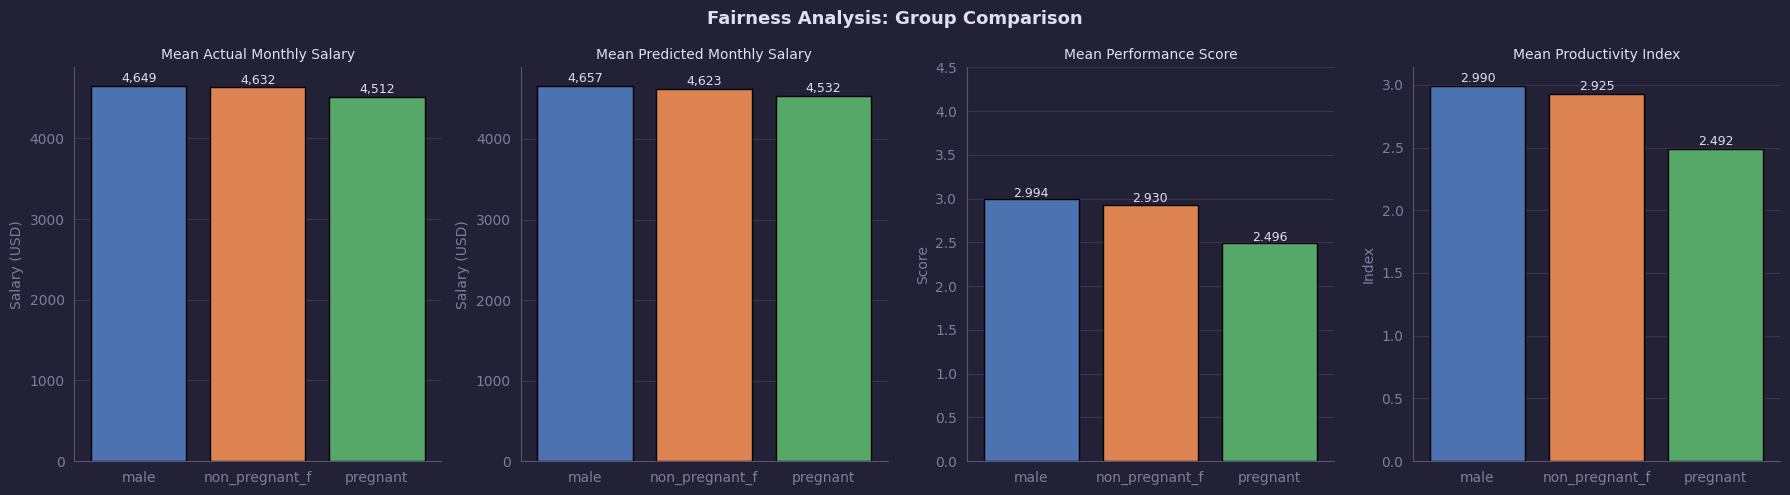

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
groups     = group_sal.index.tolist()
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]

metrics = [
    ("mean_actual_salary",      "Mean Actual Monthly Salary",    "Salary (USD)", None),
    ("mean_predicted_salary",   "Mean Predicted Monthly Salary", "Salary (USD)", None),
    ("mean_perf_score",         "Mean Performance Score",        "Score",        (0, 4.5)),
    ("mean_productivity_index", "Mean Productivity Index",       "Index",        None),
]

for ax, (col, title, ylabel, ylim) in zip(axes, metrics):
    vals = group_sal[col]
    ax.bar(groups, vals, color=bar_colors, edgecolor="black")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    for i, v in enumerate(vals):
        fmt = f"{v:,.0f}" if "salary" in col else f"{v:.3f}"
        ax.text(i, v * 1.01, fmt, ha="center", fontsize=9)

plt.suptitle("Fairness Analysis: Group Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [68]:
from scipy.stats import f_oneway

cols_to_test = {
    "Actual Monthly Salary":   "Monthly_Salary",
    "Predicted Monthly Salary":"predicted_salary",
    "Performance Score":       "Performance_Score",
    "Productivity Index":      "productivity_index",
}

print("ANOVA Results (H0: all group means are equal):")
for label, col in cols_to_test.items():
    group_arrays = [df_bias[df_bias["group"] == g][col].values for g in groups]
    f_val, p_val = f_oneway(*group_arrays)
    sig = "→ significant ⚠" if p_val < 0.05 else "→ not significant ✓"
    print(f"  {label:<35}: F={f_val:.4f}, p={p_val:.4f}  {sig}")

ANOVA Results (H0: all group means are equal):
  Actual Monthly Salary              : F=1.1136, p=0.3286  → not significant ✓
  Predicted Monthly Salary           : F=0.9317, p=0.3941  → not significant ✓
  Performance Score                  : F=102.0324, p=0.0000  → significant ⚠
  Productivity Index                 : F=139.4572, p=0.0000  → significant ⚠


Salary Gap by Group (positive = model underpredicts):
                Mean Gap (Actual - Predicted)  Std Gap
group                                                 
male                                    -7.63   527.28
non_pregnant_f                           9.18   535.10
pregnant                               -19.92   515.37


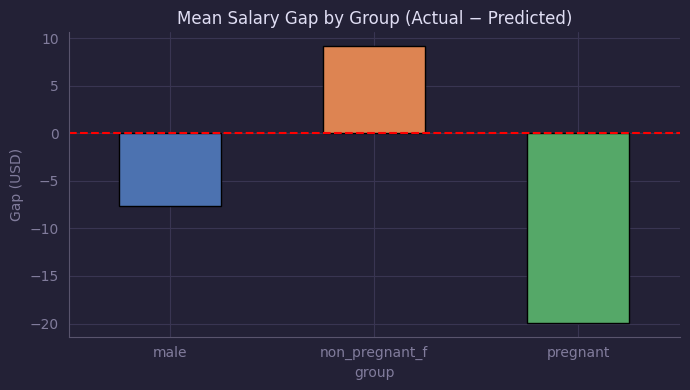

In [69]:
df_bias["salary_gap"] = df_bias["Monthly_Salary"] - df_bias["predicted_salary"]

gap_summary = df_bias.groupby("group")["salary_gap"].agg(["mean", "std"]).round(2)
gap_summary.columns = ["Mean Gap (Actual - Predicted)", "Std Gap"]
print("Salary Gap by Group (positive = model underpredicts):")
print(gap_summary.to_string())

gap_summary["Mean Gap (Actual - Predicted)"].plot(
    kind="bar", color=bar_colors[:len(groups)], edgecolor="black", figsize=(7, 4)
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Mean Salary Gap by Group (Actual − Predicted)")
plt.ylabel("Gap (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

- **Actual vs Predicted salary**: if the model over- or under-predicts for a specific group, proxy features may carry indirect group information.
- **Salary gap plot**: a positive gap means the model underpredicts actual salary for that group; a negative gap means it overpredicts.
- **Performance & Productivity**: shows whether salary differences across groups are proportional to the performance and productivity differences captured in the data — or whether there is a residual unexplained component indicating inequity.
- **ANOVA**: a significant p-value (< 0.05) on **predicted salary** across groups signals that model outputs correlate with group membership despite the group column being excluded.

This notebook was updated by `La Wun Nannda`.